# Demo can chinh khuon mat voi SCRFD + ArcFace

Notebook nay minh hoa toan bo pipeline theo tung buoc:

1. Detect khuon mat tren `assets/faces/Joey.png` va plot ket qua
2. Crop khuon mat chua can chinh va plot anh crop
3. Crop khuon mat da can chinh theo 5 landmarks
4. Lap lai voi `assets/faces/Monica.png`
5. Trich xuat 2 vector dac trung va tinh do tuong dong cosine

> Truoc khi chay notebook, hay cai dependency bang `python -m pip install -r requirements.txt`.


In [1]:
from pathlib import Path
import logging

import cv2
import matplotlib.pyplot as plt
import numpy as np

from models.scrfd import SCRFD
from models.arcface import ArcFace
from utils.helpers import compute_similarity, face_alignment

logging.getLogger("models.scrfd").setLevel(logging.ERROR)
logging.getLogger("models.arcface").setLevel(logging.ERROR)
np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path.cwd()
WEIGHTS_DIR = REPO_ROOT / "weights"
FACES_DIR = REPO_ROOT / "assets" / "faces"

joey_path = FACES_DIR / "Joey.png"
monica_path = FACES_DIR / "Monica.png"
detector_path = WEIGHTS_DIR / "det_10g.onnx"
encoder_path = WEIGHTS_DIR / "w600k_mbf.onnx"

for path in [joey_path, monica_path, detector_path, encoder_path]:
    assert path.exists(), f"Khong tim thay file: {path}"

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_image(image, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(bgr_to_rgb(image))
    ax.set_title(title)
    ax.axis("off")

def draw_detection(image, bbox, landmarks):
    canvas = image.copy()
    x1, y1, x2, y2 = bbox[:4].astype(int)
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for x, y in landmarks.astype(int):
        cv2.circle(canvas, (x, y), 4, (255, 0, 0), -1)
    return canvas

def crop_from_bbox(image, bbox, margin=0.1):
    height, width = image.shape[:2]
    x1, y1, x2, y2 = bbox[:4]
    box_width = x2 - x1
    box_height = y2 - y1
    x1 = max(0, int(x1 - box_width * margin))
    y1 = max(0, int(y1 - box_height * margin))
    x2 = min(width, int(x2 + box_width * margin))
    y2 = min(height, int(y2 + box_height * margin))
    return image[y1:y2, x1:x2]

def detect_primary_face(image, detector, image_name):
    detections, keypoints = detector.detect(image, max_num=1)
    if detections.size == 0 or keypoints is None:
        raise RuntimeError(f"Khong detect duoc khuon mat trong {image_name}")
    return detections[0], keypoints[0]

def get_embedding_from_aligned_face(aligned_face, encoder, normalized=True):
    face_blob = encoder.preprocess(aligned_face)
    embedding = encoder.session.run(encoder.output_names, {encoder.input_name: face_blob})[0].flatten()
    if normalized:
        embedding = embedding / np.linalg.norm(embedding)
    return embedding

detector = SCRFD(str(detector_path))
encoder = ArcFace(str(encoder_path))
print("Da load xong SCRFD va ArcFace.")


Da load xong SCRFD va ArcFace.


## Buoc 1. Detect khuon mat tren Joey

Model `SCRFD` tra ve `bbox` va 5 facial landmarks. Day la dau vao cho buoc can chinh o phia sau.


Joey bbox: [144.35  64.08 322.37 308.64   0.89]
Joey landmarks:
 [[179.17 153.19]
 [253.27 171.8 ]
 [194.94 211.12]
 [170.16 221.2 ]
 [252.06 238.83]]


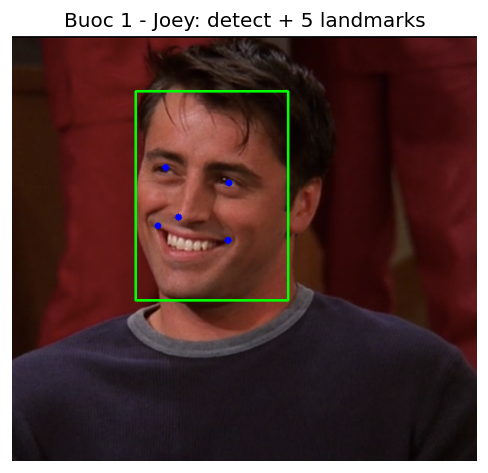

In [2]:
joey_image = cv2.imread(str(joey_path))
joey_bbox, joey_landmarks = detect_primary_face(joey_image, detector, "Joey.png")

print("Joey bbox:", np.round(joey_bbox, 2))
print("Joey landmarks:\n", np.round(joey_landmarks, 2))

show_image(
    draw_detection(joey_image, joey_bbox, joey_landmarks),
    "Buoc 1 - Joey: detect + 5 landmarks",
)


## Buoc 2. Crop khuon mat chua can chinh

Crop nay chi cat theo `bbox`, chua dua hai mat va mui ve vi tri chuan.


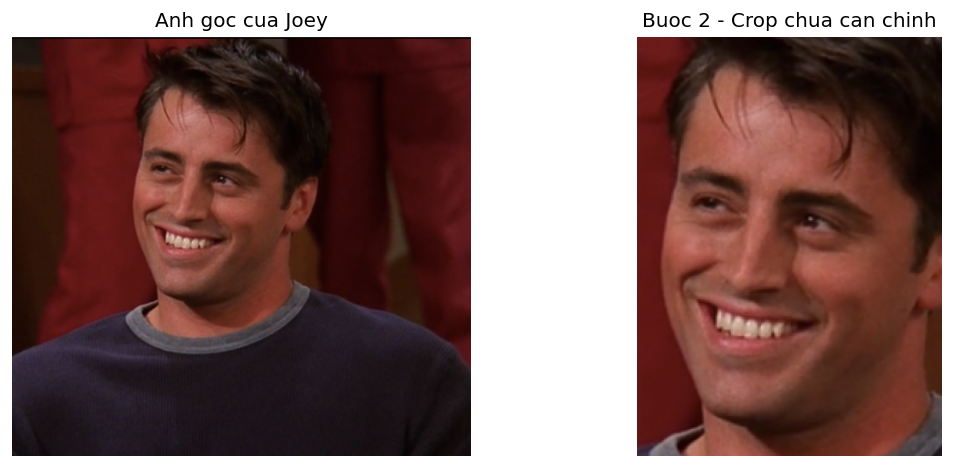

In [4]:
joey_raw_crop = crop_from_bbox(joey_image, joey_bbox, margin=0.1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_image(joey_image, "Anh goc cua Joey", axes[0])
show_image(joey_raw_crop, "Buoc 2 - Crop chua can chinh", axes[1])
plt.tight_layout()


## Buoc 3. Can chinh khuon mat cua Joey

Ham `face_alignment(...)` dung 5 landmarks de warp anh ve kich thuoc chuan `112x112`.


Inverse alignment matrix cua Joey:
 [[  2.1364  -0.3339 114.2329]
 [  0.3339   2.1364  26.9076]]


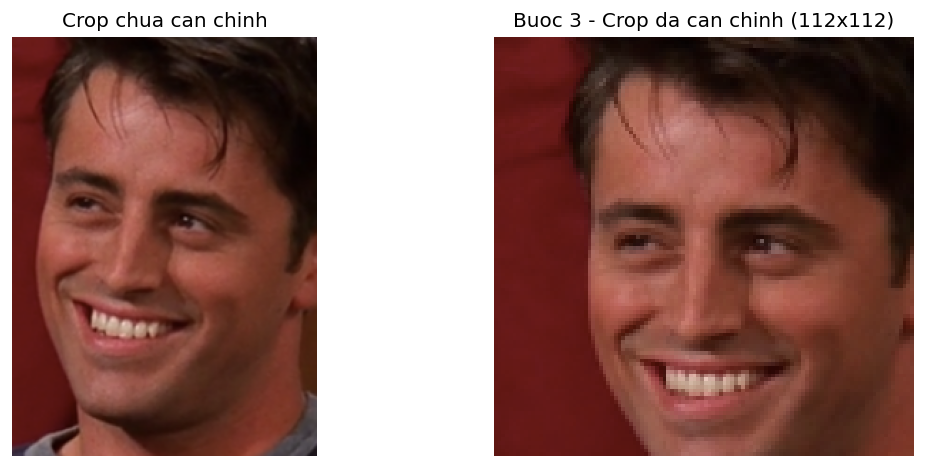

In [5]:
joey_aligned, joey_inverse_matrix = face_alignment(joey_image, joey_landmarks)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_image(joey_raw_crop, "Crop chua can chinh", axes[0])
show_image(joey_aligned, "Buoc 3 - Crop da can chinh (112x112)", axes[1])
plt.tight_layout()

print("Inverse alignment matrix cua Joey:\n", np.round(joey_inverse_matrix, 4))


## Buoc 4. Crop them 1 khuon mat voi Monica

Minh lap lai pipeline detect -> crop thuan -> crop da can chinh cho `assets/faces/Monica.png`.


Monica bbox: [147.98  79.12 284.87 274.19   0.86]
Monica landmarks:
 [[185.12 156.58]
 [252.46 147.31]
 [227.26 194.34]
 [196.39 224.12]
 [257.81 215.52]]


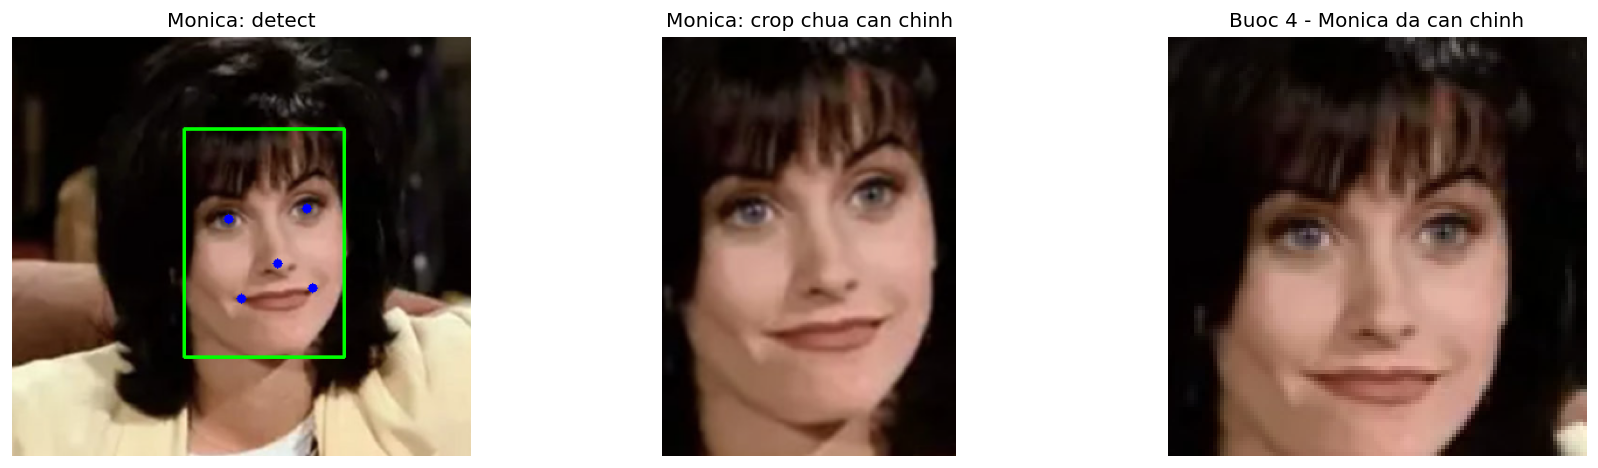

In [6]:
monica_image = cv2.imread(str(monica_path))
monica_bbox, monica_landmarks = detect_primary_face(monica_image, detector, "Monica.png")
monica_raw_crop = crop_from_bbox(monica_image, monica_bbox, margin=0.1)
monica_aligned, _ = face_alignment(monica_image, monica_landmarks)

print("Monica bbox:", np.round(monica_bbox, 2))
print("Monica landmarks:\n", np.round(monica_landmarks, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show_image(draw_detection(monica_image, monica_bbox, monica_landmarks), "Monica: detect", axes[0])
show_image(monica_raw_crop, "Monica: crop chua can chinh", axes[1])
show_image(monica_aligned, "Buoc 4 - Monica da can chinh", axes[2])
plt.tight_layout()


## Buoc 5. Trich xuat dac trung va tinh cosine similarity

ArcFace nhan anh da can chinh va tra ve embedding 512 chieu. Sau do dung `compute_similarity(...)` de tinh do tuong dong cosine.


Joey embedding shape: (512,)
Joey embedding[:10]: [-0.0524 -0.0028 -0.0062 -0.0788 -0.0624  0.0281  0.0465  0.0896  0.0707
 -0.0402]

Monica embedding shape: (512,)
Monica embedding[:10]: [ 0.0164 -0.0331  0.071   0.016   0.035   0.0685 -0.0512 -0.0267 -0.0459
 -0.0105]

Cosine similarity (Joey vs Monica): 0.027505356818437576


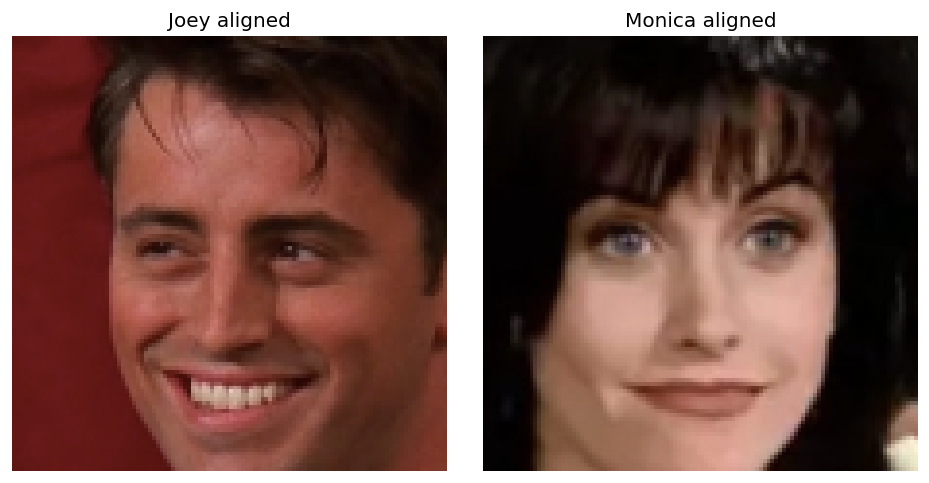

In [7]:
joey_embedding = get_embedding_from_aligned_face(joey_aligned, encoder, normalized=True)
monica_embedding = get_embedding_from_aligned_face(monica_aligned, encoder, normalized=True)
cosine_similarity = compute_similarity(joey_embedding, monica_embedding)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_image(joey_aligned, "Joey aligned", axes[0])
show_image(monica_aligned, "Monica aligned", axes[1])
plt.tight_layout()

print("Joey embedding shape:", joey_embedding.shape)
print("Joey embedding[:10]:", np.round(joey_embedding[:10], 4))
print()
print("Monica embedding shape:", monica_embedding.shape)
print("Monica embedding[:10]:", np.round(monica_embedding[:10], 4))
print()
print("Cosine similarity (Joey vs Monica):", float(cosine_similarity))
